# Data Processing

In [1]:
%load_ext autoreload
%autoreload 2

Specify Model class in [nba/models.py](nba/models.py) with the corresponding ```.yaml``` config. The build_model method in [nba/models.py](nba/models.py) loads the model from the config.

We can pass a model with it's config the following way:

In [2]:
from config.config import Config
from nba import NBATrainer, NBASubmission, NBAVisualizer

cfg = Config(path="config/spacetime_gnn.yaml").load()

trainer = NBATrainer(cfg)

Training on cuda


## k-fold training/prediction

K-fold training method splits the training set into k partitions and always trains on k-1 partitions and validates/tests on the last partition, with early stopping. In the end we get the avg. test loss and a plot for validation and training losses over epochs in the folder ```saved_models/MODEL_NAME``` (MODEL_NAME specified in .yaml).

The best modelcheckpoint over the folds is saved in the same folder such that we can then run the visualization metrics (but for the submission we then want to train on all the training data we have).

  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
Fold 0 | Test Loss: 0.0251
  [EarlyStopping] Counter 1 of 5
  [EarlyStopping] Counter 1 of 5
Fold 1 | Test Loss: 0.0227
  [EarlyStopping] Counter 1 of 5
Fold 2 | Test Loss: 0.0223
  [EarlyStopping] Counter 1 of 5
Fold 3 | Test Loss: 0.0261
Logs saved to saved_models/SpaceTimeGNN/kfold_results.json


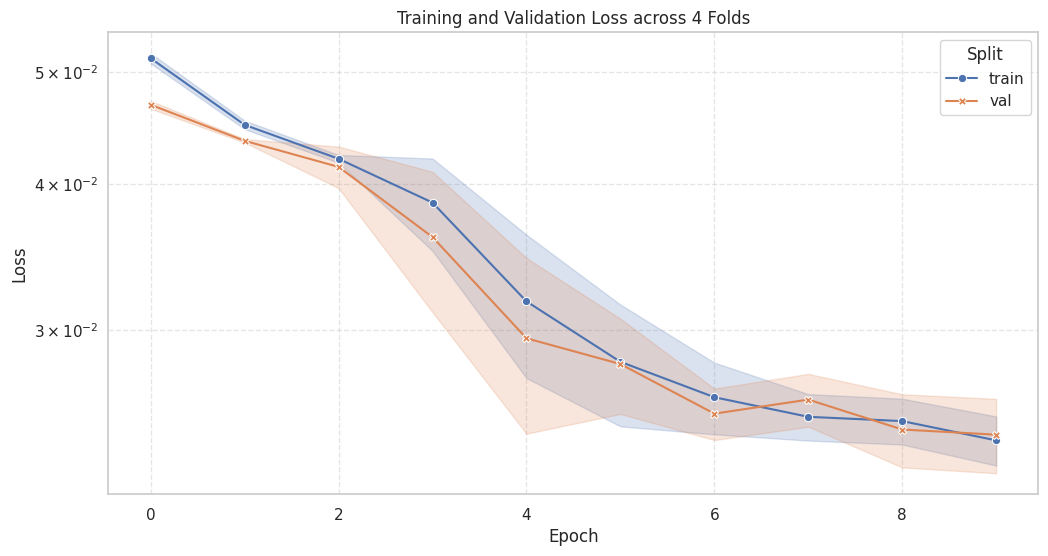

Training stats plot saved to saved_models/SpaceTimeGNN/kfold_plot.png
Training finished
Avg. test loss over folds: 0.024059996102005245


In [3]:
trainer.train_k_fold(k=4)

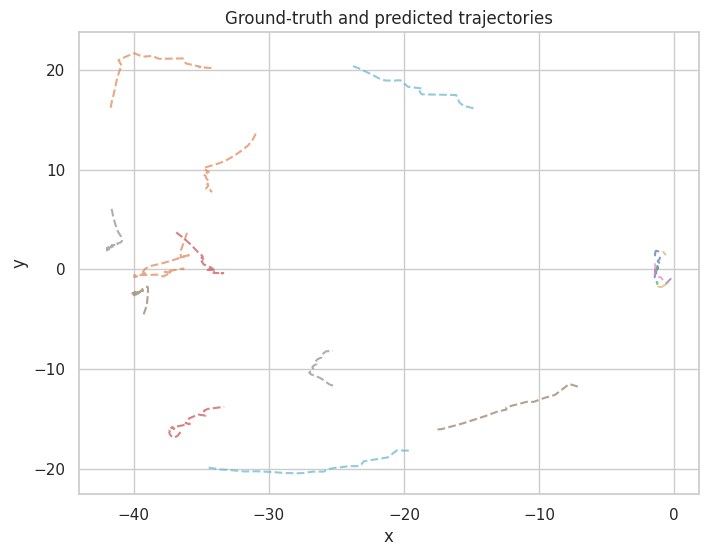

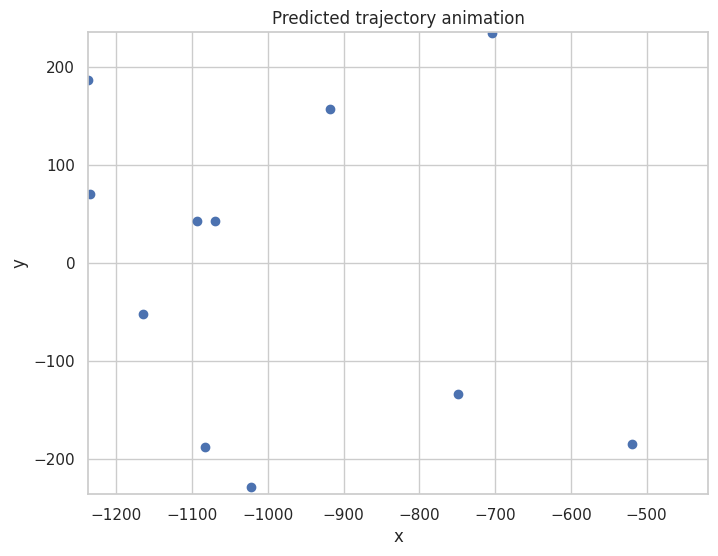

In [4]:
viz = NBAVisualizer(cfg, trainer)
viz.plot_example()
viz.animate_example()

##### k-fold example for another training architecture

In [7]:
cfg = Config(path="config/spacetime_gnn.yaml").load()
trainer = NBATrainer(cfg)

Training on cuda


Fold 0 | Test Loss: 0.0251
Fold 1 | Test Loss: 0.0269
Logs saved to saved_models/SpaceTimeGNN/kfold_results.json


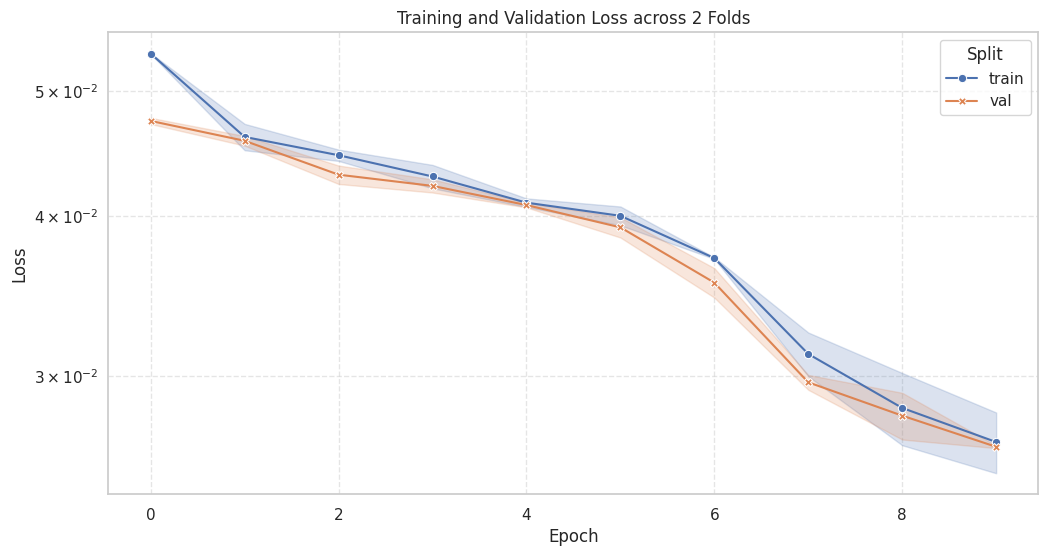

Training stats plot saved to saved_models/SpaceTimeGNN/kfold_plot.png
Training finished
Avg. test loss over folds: 0.02602390698157251


In [8]:
trainer.train_k_fold(k=2)

## train on all the data

To train on all the training data we have, we can just run the train method on the traininer (which then overrides the checkpoint.pth from the k-fold), therefore the visualizations and predictions are then on this checkpoint. Here, no early stopping is implemented, so we'd have to adjust the config. 

In [2]:
from config.config import Config
from nba import NBATrainer, NBASubmission, NBAVisualizer

cfg = Config(path="config/spacetime_gnn.yaml").load()
trainer = NBATrainer(cfg)

trainer.train_with_early_stopping()
sub = NBASubmission(cfg, trainer)
sub.create()

Training on cuda


Epoch 1/50
  [TRAIN] Loss: 0.0522 | [TEST] Loss: 0.0487
Epoch 2/50
  [TRAIN] Loss: 0.0453 | [TEST] Loss: 0.0461
Epoch 3/50
  [TRAIN] Loss: 0.0437 | [TEST] Loss: 0.0448
Epoch 4/50
  [TRAIN] Loss: 0.0431 | [TEST] Loss: 0.0450
  [EarlyStopping] Counter 1 of 5
Epoch 5/50
  [TRAIN] Loss: 0.0423 | [TEST] Loss: 0.0452
  [EarlyStopping] Counter 2 of 5
Epoch 6/50
  [TRAIN] Loss: 0.0425 | [TEST] Loss: 0.0442
Epoch 7/50
  [TRAIN] Loss: 0.0418 | [TEST] Loss: 0.0437
Epoch 8/50
  [TRAIN] Loss: 0.0413 | [TEST] Loss: 0.0432
Epoch 9/50
  [TRAIN] Loss: 0.0413 | [TEST] Loss: 0.0436
  [EarlyStopping] Counter 1 of 5
Epoch 10/50
  [TRAIN] Loss: 0.0415 | [TEST] Loss: 0.0426
Epoch 11/50
  [TRAIN] Loss: 0.0415 | [TEST] Loss: 0.0427
  [EarlyStopping] Counter 1 of 5
Epoch 12/50
  [TRAIN] Loss: 0.0412 | [TEST] Loss: 0.0435
  [EarlyStopping] Counter 2 of 5
Epoch 13/50
  [TRAIN] Loss: 0.0417 | [TEST] Loss: 0.0435
  [EarlyStopping] Counter 3 of 5
Epoch 14/50
  [TRAIN] Loss: 0.0411 | [TEST] Loss: 0.0431
  [EarlyStopp

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
test_loss,█▇▇▇▇▆▆▆▆▆▆▆▆▆▆▅▅▄▄▃▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▆▆▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
test_loss,0.02619
train_loss,0.02471


Submission saved to data/submission/solution.csv


,entity_0_time_0_x,entity_0_time_0_y,entity_1_time_0_x,entity_1_time_0_y,entity_2_time_0_x,entity_2_time_0_y,entity_3_time_0_x,entity_3_time_0_y,entity_4_time_0_x,entity_4_time_0_y,...,entity_6_time_11_x,entity_6_time_11_y,entity_7_time_11_x,entity_7_time_11_y,entity_8_time_11_x,entity_8_time_11_y,entity_9_time_11_x,entity_9_time_11_y,entity_10_time_11_x,entity_10_time_11_y
id,,,,,,,,,,,,,,,,,,,,,
0,-12.536382,-7.401149,-24.339911,5.994840,-40.468731,-13.014367,-22.506346,-5.608198,-34.837578,1.920933,...,-41.810760,8.990188,-20.235455,-4.913942,-36.106411,9.993581,-26.590719,19.749792,-40.822735,-20.206251
1,-21.123955,-2.269719,-29.683737,14.069574,-34.354290,-18.815550,-23.347183,-7.544400,-42.244282,0.862307,...,-22.569944,15.275048,-29.615915,1.444111,-32.655872,-18.809591,-20.791573,-1.945958,-18.057871,-8.148830
2,41.290951,0.433904,40.444546,-1.079058,34.009232,-0.246887,29.569075,7.970444,39.516460,8.089927,...,39.387688,-2.038074,13.024158,-8.370764,34.746838,3.747923,21.501263,11.742287,25.697340,17.096056
3,-41.080620,1.194117,-40.640518,-3.714715,-39.112331,-2.367502,-23.209778,11.609653,-21.447763,-4.137138,...,-22.199850,18.641844,-22.481186,21.637272,1.417722,13.339476,21.216452,5.973348,-31.817459,4.047643
4,42.354237,-5.714156,13.818147,9.900491,41.412651,-16.408537,41.315197,5.298694,15.201500,-6.024336,...,31.159283,-4.005224,32.103981,17.987917,40.072380,7.723101,32.597942,0.160466,39.419506,-14.974078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,-40.520988,0.017797,-38.666191,-21.240551,-40.559685,-8.452768,-44.044811,-11.398040,-35.086613,3.483483,...,-13.467375,15.156021,-36.369251,1.522197,-36.598625,-10.853865,-13.233094,10.296828,-22.278969,-4.050894
1239,-13.933862,11.535666,-39.536640,-13.300867,-20.217876,8.715198,-38.106773,19.167017,-22.592901,3.027446,...,-39.368015,20.099901,-37.037235,-7.039047,-22.443769,9.322862,-20.816422,2.024951,-37.724449,-20.147108
1240,-16.247440,1.200693,-18.469194,-6.469627,-30.386572,-7.547935,-23.275335,-3.155528,-21.038372,9.338367,...,-29.937578,14.613287,-9.368660,11.185376,-17.325285,10.303309,-8.579776,-1.221201,-26.564976,-11.883993
